# Arabic Text Classification - Traditional ML
This notebook compares traditional machine learning models across multiple preprocessing variants and representations.
It includes the original dataset plus all CSVs in the preprocessed datasets folder.

## Goals
- Compare preprocessing variants vs the original dataset.
- Evaluate multiple text representations and traditional ML models.
- Report accuracy, precision, recall, and F1 scores.
- Visualize results with bar plots and a Sankey diagram.

## 1. Setup

In [15]:
import os
import glob
import json
import random
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from tqdm import tqdm
import joblib

warnings.filterwarnings("ignore")

In [21]:
# The ELMo and Allennlp installation is consistently failing due to spacy build issues.

!pip install --upgrade pip wheel --quiet
!pip install setuptools==60.0.0 --quiet
!pip install xgboost plotly gensim pyarabic --quiet

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import TruncatedSVD

from gensim.models import Word2Vec, FastText
from gensim.models.keyedvectors import KeyedVectors

from xgboost import XGBClassifier
import scipy.sparse as sp

In [17]:
import torch
from transformers import AutoTokenizer, AutoModel

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

## 2. Configuration

In [18]:
SEED = 42
TEST_SIZE = 0.2
RANDOM_STATE = 42

DATASET_ROOT = "."
PREPROCESSED_DIR = os.path.join(DATASET_ROOT, "preprocessed datasets")
ORIGINAL_DATASET = "/content/AAFAQ_Dataset.csv"

CACHE_DIR = os.path.join(DATASET_ROOT, "feature_cache")
OUTPUT_DIR = os.path.join(DATASET_ROOT, "outputs")
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

BERT_MODEL_NAME = "aubmindlab/bert-base-arabertv02"
GPT_MODEL_NAME = "aubmindlab/aragpt2-base"

GLOVE_PATH = os.path.join(DATASET_ROOT, "models", "glove_arabic.txt")
GLOVE_DIM = 100
ELMO_MODEL_DIR = os.path.join(DATASET_ROOT, "models", "elmo_arabic")

MAX_VOCAB = 50000
METRIC_FOR_SANKEY = "Macro F1"
BATCH_SIZE_EMBEDDINGS = 16

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 3. Dataset Registry

In [19]:
def build_dataset_registry():
    registry = {"Original (raw)": ORIGINAL_DATASET}
    if os.path.isdir(PREPROCESSED_DIR):
        for path in sorted(glob.glob(os.path.join(PREPROCESSED_DIR, "*.csv"))):
            base = os.path.splitext(os.path.basename(path))[0]
            display = base.replace("_", " ")
            registry[display] = path
    return registry

DATASET_REGISTRY = build_dataset_registry()
pd.DataFrame(
    [{"Dataset": k, "Path": v} for k, v in DATASET_REGISTRY.items()]
).head(20)

,Dataset,Path
0,Original (raw),./AAFAQ_Dataset.csv
1,pyarabic aggressive preprocessed,./preprocessed datasets/pyarabic_aggressive_pr...
2,pyarabic hamza only preprocessed,./preprocessed datasets/pyarabic_hamza_only_pr...
3,pyarabic hamza tashkeel preprocessed,./preprocessed datasets/pyarabic_hamza_tashkee...
4,pyarabic punctuation only preprocessed,./preprocessed datasets/pyarabic_punctuation_o...
5,pyarabic tashkeel tatweel preprocessed,./preprocessed datasets/pyarabic_tashkeel_tatw...
6,regex aggressive preprocessed,./preprocessed datasets/regex_aggressive_prepr...


In [25]:
def load_dataset(path):
    df = pd.read_csv(path)
    required = {"QuestionText", "Category"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns {missing} in {path}")
    df = df.dropna(subset=["QuestionText", "Category"]).reset_index(drop=True)
    df["QuestionText"] = df["QuestionText"].astype(str).str.strip()
    df = df[df["QuestionText"].str.len() > 0].reset_index(drop=True)
    le = LabelEncoder()
    df["Label"] = le.fit_transform(df["Category"])
    return df, le

datasets = {}
label_encoders = {}
for name, path in DATASET_REGISTRY.items():
    df, le = load_dataset(path)
    datasets[name] = df
    label_encoders[name] = le

dataset_stats = pd.DataFrame(
    [{"Dataset": k, "Rows": v.shape[0], "Categories": v["Category"].nunique()} for k, v in datasets.items()]
).sort_values("Rows", ascending=False)
dataset_stats

,Dataset,Rows,Categories
0,Original (raw),5009,17
1,pyarabic aggressive preprocessed,5009,17
2,pyarabic hamza only preprocessed,5009,17
3,pyarabic hamza tashkeel preprocessed,5009,17
4,pyarabic punctuation only preprocessed,5009,17
5,pyarabic tashkeel tatweel preprocessed,5009,17
6,regex aggressive preprocessed,5009,17


## 4. EDA - Category Distribution

In [28]:
!pip install arabic-reshaper python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [arabic-reshaper]


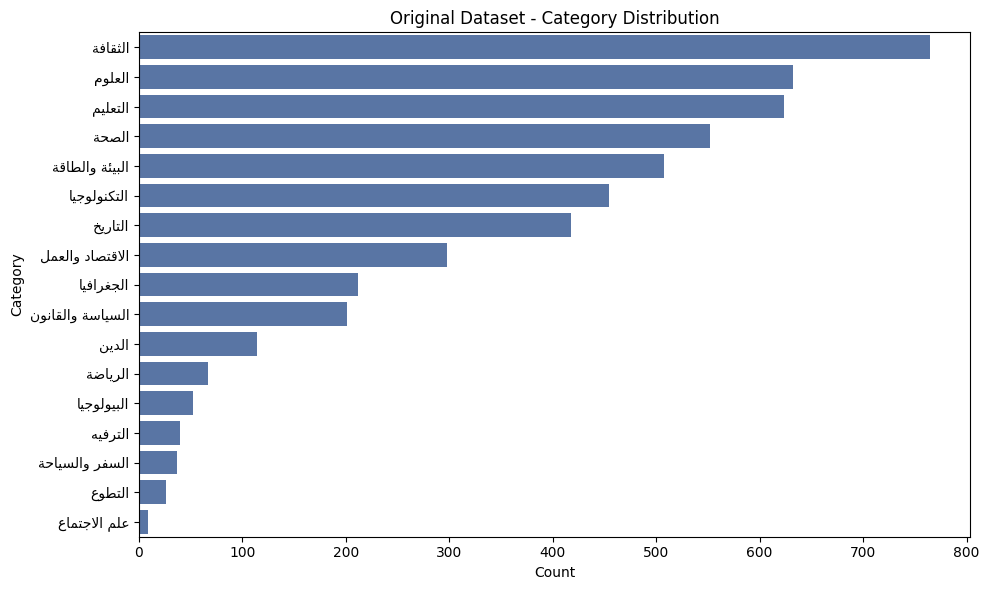

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# these libraries help fix the visualization issues with the arabic text
import arabic_reshaper
from bidi.algorithm import get_display

# Set a font that supports Arabic characters globally
plt.rcParams['font.family'] = 'DejaVu Sans'  # Use 'Arial' or 'Tahoma' if on Windows

def plot_category_distribution(df, title):
    counts = df["Category"].value_counts().sort_values(ascending=False)

    # FIX: Reshape and reverse the Arabic text in the category indices
    formatted_index = [get_display(arabic_reshaper.reshape(str(cat))) for cat in counts.index]

    # Optional: Fix Arabic characters in the title if it contains Arabic
    formatted_title = get_display(arabic_reshaper.reshape(title))

    plt.figure(figsize=(10, 6))

    # Pass the formatted_index as the y-variable
    sns.barplot(x=counts.values, y=formatted_index, color="#4C72B0")

    plt.title(formatted_title)
    plt.xlabel("Count")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()

# Run the function
plot_category_distribution(datasets["Original (raw)"], "Original Dataset - Category Distribution")


In [31]:
eda_rows = []
for name, df in datasets.items():
    top = df["Category"].value_counts().head(5)
    for cat, cnt in top.items():
        eda_rows.append({"Dataset": name, "Category": cat, "Count": int(cnt)})
pd.DataFrame(eda_rows).head(20)

,Dataset,Category,Count
0,Original (raw),الثقافة,765
1,Original (raw),العلوم,632
2,Original (raw),التعليم,624
3,Original (raw),الصحة,552
4,Original (raw),البيئة والطاقة,508
5,pyarabic aggressive preprocessed,الثقافة,765
6,pyarabic aggressive preprocessed,العلوم,632
7,pyarabic aggressive preprocessed,التعليم,624
8,pyarabic aggressive preprocessed,الصحة,552
9,pyarabic aggressive preprocessed,البيئة والطاقة,508


## 5. Train/Test Split and Tokenization

In [32]:
def split_dataset(df):
    X = df["QuestionText"].tolist()
    y = df["Label"].values
    return train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

def simple_tokenize(texts):
    return [str(t).split() for t in texts]

## 6. Feature Extraction - Bag of Words

In [33]:
def bow_features(X_train, X_test, cache_key):
    cache_path = os.path.join(CACHE_DIR, f"{cache_key}_bow.joblib")
    if os.path.exists(cache_path):
        vec, X_train_vec, X_test_vec = joblib.load(cache_path)
        return X_train_vec, X_test_vec
    vec = CountVectorizer(max_features=5000, ngram_range=(1, 2))
    X_train_vec = vec.fit_transform(X_train)
    X_test_vec = vec.transform(X_test)
    joblib.dump((vec, X_train_vec, X_test_vec), cache_path)
    return X_train_vec, X_test_vec

## 7. Feature Extraction - TF-IDF

In [34]:
def tfidf_features(X_train, X_test, cache_key):
    cache_path = os.path.join(CACHE_DIR, f"{cache_key}_tfidf.joblib")
    if os.path.exists(cache_path):
        vec, X_train_vec, X_test_vec = joblib.load(cache_path)
        return X_train_vec, X_test_vec
    vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X_train_vec = vec.fit_transform(X_train)
    X_test_vec = vec.transform(X_test)
    joblib.dump((vec, X_train_vec, X_test_vec), cache_path)
    return X_train_vec, X_test_vec

## 8. Embeddings - Word2Vec / FastText

In [35]:
def average_embeddings(tokens_list, model, vector_size):
    vectors = np.zeros((len(tokens_list), vector_size), dtype=np.float32)
    for i, tokens in enumerate(tokens_list):
        valid = [model.wv[w] for w in tokens if w in model.wv]
        if valid:
            vectors[i] = np.mean(valid, axis=0)
    return vectors

def word2vec_features(X_train, X_test, cache_key, sg=1, vector_size=100):
    cache_path = os.path.join(CACHE_DIR, f"{cache_key}_w2v_sg{sg}.joblib")
    if os.path.exists(cache_path):
        return joblib.load(cache_path)
    tokens_train = simple_tokenize(X_train)
    tokens_test = simple_tokenize(X_test)
    model = Word2Vec(
        sentences=tokens_train,
        vector_size=vector_size,
        window=5,
        min_count=2,
        workers=4,
        sg=sg,
        seed=SEED,
    )
    X_train_vec = average_embeddings(tokens_train, model, vector_size)
    X_test_vec = average_embeddings(tokens_test, model, vector_size)
    joblib.dump((X_train_vec, X_test_vec), cache_path)
    return X_train_vec, X_test_vec

def fasttext_features(X_train, X_test, cache_key, vector_size=100):
    cache_path = os.path.join(CACHE_DIR, f"{cache_key}_fasttext.joblib")
    if os.path.exists(cache_path):
        return joblib.load(cache_path)
    tokens_train = simple_tokenize(X_train)
    tokens_test = simple_tokenize(X_test)
    model = FastText(
        sentences=tokens_train,
        vector_size=vector_size,
        window=5,
        min_count=2,
        workers=4,
        seed=SEED,
    )
    X_train_vec = average_embeddings(tokens_train, model, vector_size)
    X_test_vec = average_embeddings(tokens_test, model, vector_size)
    joblib.dump((X_train_vec, X_test_vec), cache_path)
    return X_train_vec, X_test_vec

## 9. Embeddings - GloVe

In [36]:
def load_glove_embeddings(path, dim):
    embeddings = {}
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != dim + 1:
                continue
            word = parts[0]
            vec = np.asarray(parts[1:], dtype=np.float32)
            embeddings[word] = vec
    return embeddings

def glove_features(X_train, X_test, cache_key, dim=GLOVE_DIM):
    cache_path = os.path.join(CACHE_DIR, f"{cache_key}_glove.joblib")
    if os.path.exists(cache_path):
        return joblib.load(cache_path)
    if not os.path.exists(GLOVE_PATH):
        raise FileNotFoundError(f"GloVe file not found: {GLOVE_PATH}")
    embeddings = load_glove_embeddings(GLOVE_PATH, dim)
    def avg_glove(tokens):
        vecs = [embeddings[w] for w in tokens if w in embeddings]
        if not vecs:
            return np.zeros(dim, dtype=np.float32)
        return np.mean(vecs, axis=0)
    tokens_train = simple_tokenize(X_train)
    tokens_test = simple_tokenize(X_test)
    X_train_vec = np.vstack([avg_glove(t) for t in tokens_train])
    X_test_vec = np.vstack([avg_glove(t) for t in tokens_test])
    joblib.dump((X_train_vec, X_test_vec), cache_path)
    return X_train_vec, X_test_vec

## 10. Embeddings - ELMo (optional)

In [37]:
def elmo_features(X_train, X_test, cache_key):
    cache_path = os.path.join(CACHE_DIR, f"{cache_key}_elmo.joblib")
    if os.path.exists(cache_path):
        return joblib.load(cache_path)
    if not os.path.isdir(ELMO_MODEL_DIR):
        raise FileNotFoundError(f"ELMo model directory not found: {ELMO_MODEL_DIR}")
    try:
        from allennlp.modules.elmo import Elmo, batch_to_ids
    except ImportError as exc:
        raise ImportError("Install allennlp to use ELMo features") from exc
    options_path = os.path.join(ELMO_MODEL_DIR, "options.json")
    weight_path = os.path.join(ELMO_MODEL_DIR, "weights.hdf5")
    elmo = Elmo(options_path, weight_path, 2, dropout=0.0)
    def embed(texts):
        tokens = [str(t).split() for t in texts]
        char_ids = batch_to_ids(tokens)
        with torch.no_grad():
            embeddings = elmo(char_ids)["elmo_representations"][0]
        return embeddings.mean(dim=1).cpu().numpy()
    X_train_vec = embed(X_train)
    X_test_vec = embed(X_test)
    joblib.dump((X_train_vec, X_test_vec), cache_path)
    return X_train_vec, X_test_vec

## 11. Embeddings - BERT and GPT (sentence embeddings)

In [38]:
def transformer_sentence_embeddings(texts, model_name, batch_size=16, max_length=128):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = AutoModel.from_pretrained(model_name)
    model.to(device)
    model.eval()
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}
        with torch.no_grad():
            outputs = model(**encoded)
            hidden = outputs.last_hidden_state
        mask = encoded["attention_mask"].unsqueeze(-1)
        summed = (hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1)
        mean_pool = (summed / counts).cpu().numpy()
        embeddings.append(mean_pool)
    return np.vstack(embeddings)

def transformer_features(X_train, X_test, cache_key, model_name):
    cache_path = os.path.join(CACHE_DIR, f"{cache_key}_{model_name.replace('/', '_')}.joblib")
    if os.path.exists(cache_path):
        return joblib.load(cache_path)
    X_train_vec = transformer_sentence_embeddings(X_train, model_name, batch_size=BATCH_SIZE_EMBEDDINGS)
    X_test_vec = transformer_sentence_embeddings(X_test, model_name, batch_size=BATCH_SIZE_EMBEDDINGS)
    joblib.dump((X_train_vec, X_test_vec), cache_path)
    return X_train_vec, X_test_vec

## 12. Models and Metrics

In [39]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Macro Precision": precision_score(y_test, preds, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_test, preds, average="macro", zero_division=0),
        "Macro F1": f1_score(y_test, preds, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_test, preds, average="weighted", zero_division=0),
    }

def get_models():
    return {
        "MultinomialNB": MultinomialNB(),
        "SVC": svc(),
        "XGBoost": XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softmax",
            eval_metric="mlogloss",
            n_jobs=4,
        ),
    }

## 13. Run Experiments (Traditional Features)

In [40]:
def get_models_for_dataset(num_classes):
    return {
        "MultinomialNB": MultinomialNB(),
        "SVC": SVC(),
        "XGBoost": XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            eval_metric="mlogloss",
            n_jobs=4,
            num_class=num_classes,
        ),
    }

def run_experiments(datasets):
    feature_builders = [
        ("BoW", lambda Xtr, Xte, key: bow_features(Xtr, Xte, key)),
        ("TF-IDF", lambda Xtr, Xte, key: tfidf_features(Xtr, Xte, key)),
        ("Word2Vec-SG", lambda Xtr, Xte, key: word2vec_features(Xtr, Xte, key, sg=1)),
        ("Word2Vec-CBOW", lambda Xtr, Xte, key: word2vec_features(Xtr, Xte, key, sg=0)),
        ("FastText", lambda Xtr, Xte, key: fasttext_features(Xtr, Xte, key)),
        ("GloVe", lambda Xtr, Xte, key: glove_features(Xtr, Xte, key)),
        # ELMo feature is disabled due to persistent installation issues with allennlp/spacy
        # ("ELMo", lambda Xtr, Xte, key: elmo_features(Xtr, Xte, key)),
        ("BERT", lambda Xtr, Xte, key: transformer_features(Xtr, Xte, key, BERT_MODEL_NAME)),
        ("GPT", lambda Xtr, Xte, key: transformer_features(Xtr, Xte, key, GPT_MODEL_NAME)),
    ]
    results = []
    errors = []
    for dataset_name, df in datasets.items():
        X_train, X_test, y_train, y_test = split_dataset(df)
        num_classes = len(np.unique(y_train))
        models = get_models_for_dataset(num_classes)
        for feature_name, feature_fn in feature_builders:
            cache_key = f"{dataset_name.replace(' ', '_')}_{feature_name}"
            try:
                X_train_feat, X_test_feat = feature_fn(X_train, X_test, cache_key)
            except Exception as exc:
                errors.append({
                    "Dataset": dataset_name,
                    "Feature": feature_name,
                    "Error": str(exc),
                })
                continue
            for model_name, model in models.items():
                if model_name == "MultinomialNB" and feature_name not in {"BoW", "TF-IDF"}:
                    continue
                try:
                    metrics = evaluate_model(model, X_train_feat, y_train, X_test_feat, y_test)
                    row = {
                        "Dataset": dataset_name,
                        "Feature": feature_name,
                        "Model": model_name,
                    }
                    row.update(metrics)
                    results.append(row)
                except Exception as exc:
                    errors.append({
                        "Dataset": dataset_name,
                        "Feature": feature_name,
                        "Model": model_name,
                        "Error": str(exc),
                    })
    return pd.DataFrame(results), pd.DataFrame(errors)

results_df, errors_df = run_experiments(datasets)
results_path = os.path.join(OUTPUT_DIR, "traditional_results.csv")
results_df.to_csv(results_path, index=False)
results_df.head(20)

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/825k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: aubmindlab/aragpt2-base
Key                         | Status     |  | 
----------------------------+------------+--+-
h.{0...11}.attn.bias        | UNEXPECTED |  | 
h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: aubmindlab/aragpt2-base
Key                         | Status     |  | 
----------------------------+------------+--+-
h.{0...11}.attn.bias        | UNEXPECTED |  | 
h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Dataset,Feature,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Original (raw),BoW,MultinomialNB,0.666667,0.676827,0.511826,0.545074,0.658788
1,Original (raw),BoW,LinearSVM,0.714571,0.689826,0.648768,0.659912,0.713373
2,Original (raw),BoW,XGBoost,0.670659,0.598117,0.557516,0.571943,0.667608
3,Original (raw),TF-IDF,MultinomialNB,0.626747,0.458352,0.370177,0.380004,0.602580
4,Original (raw),TF-IDF,LinearSVM,0.735529,0.690113,0.637007,0.657375,0.733346
5,Original (raw),TF-IDF,XGBoost,0.642715,0.606798,0.550906,0.571780,0.641822
6,Original (raw),Word2Vec-SG,LinearSVM,0.299401,0.176166,0.170922,0.154876,0.254573
7,Original (raw),Word2Vec-SG,XGBoost,0.420160,0.417280,0.304556,0.326256,0.410671
8,Original (raw),Word2Vec-CBOW,LinearSVM,0.239521,0.210045,0.117473,0.110611,0.193949
9,Original (raw),Word2Vec-CBOW,XGBoost,0.414172,0.357901,0.294592,0.310112,0.400106


In [35]:
results_df.sort_values(by=['Macro F1'], ascending=False).head(20)

,Dataset,Feature,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
76,pyarabic punctuation only preprocessed,BERT,LinearSVM,0.761477,0.745705,0.745722,0.741922,0.761681
77,pyarabic punctuation only preprocessed,BERT,XGBoost,0.785429,0.787996,0.702339,0.734825,0.783711
60,pyarabic hamza tashkeel preprocessed,BERT,LinearSVM,0.785429,0.742916,0.717600,0.728522,0.785016
12,Original (raw),BERT,LinearSVM,0.761477,0.763425,0.705558,0.723274,0.760899
28,pyarabic aggressive preprocessed,BERT,LinearSVM,0.742515,0.727265,0.718045,0.718019,0.743113
93,pyarabic tashkeel tatweel preprocessed,BERT,XGBoost,0.777445,0.766084,0.678990,0.713737,0.776276
61,pyarabic hamza tashkeel preprocessed,BERT,XGBoost,0.771457,0.771406,0.674921,0.712325,0.769901
44,pyarabic hamza only preprocessed,BERT,LinearSVM,0.748503,0.735654,0.696728,0.709731,0.748497
14,Original (raw),GPT,LinearSVM,0.755489,0.743606,0.693755,0.707948,0.754370
94,pyarabic tashkeel tatweel preprocessed,GPT,LinearSVM,0.737525,0.725405,0.687573,0.702713,0.737361


In [67]:
results_df.sort_values(by=['Accuracy'], ascending=True).head(20)


,Dataset,Feature,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
58,pyarabic hamza tashkeel preprocessed,FastText,LinearSVM,0.156687,0.025594,0.064483,0.032348,0.073872
26,pyarabic aggressive preprocessed,FastText,LinearSVM,0.158683,0.026749,0.065186,0.033152,0.075506
74,pyarabic punctuation only preprocessed,FastText,LinearSVM,0.159681,0.032830,0.065602,0.029980,0.070370
42,pyarabic hamza only preprocessed,FastText,LinearSVM,0.162675,0.028288,0.068520,0.036828,0.082551
90,pyarabic tashkeel tatweel preprocessed,FastText,LinearSVM,0.169661,0.029071,0.071065,0.037757,0.084781
106,regex aggressive preprocessed,FastText,LinearSVM,0.170659,0.030206,0.071429,0.038562,0.086664
10,Original (raw),FastText,LinearSVM,0.172655,0.041132,0.073999,0.042210,0.093397
56,pyarabic hamza tashkeel preprocessed,Word2Vec-CBOW,LinearSVM,0.211577,0.142884,0.104019,0.094695,0.164861
88,pyarabic tashkeel tatweel preprocessed,Word2Vec-CBOW,LinearSVM,0.228543,0.141498,0.108032,0.096075,0.179905
104,regex aggressive preprocessed,Word2Vec-CBOW,LinearSVM,0.232535,0.179212,0.104403,0.080530,0.164389


In [51]:
errors_path = os.path.join(OUTPUT_DIR, "traditional_errors.csv")
errors_df.to_csv(errors_path, index=False)
errors_df.head(20)

,Dataset,Feature,Error
0,Original (raw),GloVe,GloVe file not found: ./models/glove_arabic.txt
1,pyarabic aggressive preprocessed,GloVe,GloVe file not found: ./models/glove_arabic.txt
2,pyarabic hamza only preprocessed,GloVe,GloVe file not found: ./models/glove_arabic.txt
3,pyarabic hamza tashkeel preprocessed,GloVe,GloVe file not found: ./models/glove_arabic.txt
4,pyarabic punctuation only preprocessed,GloVe,GloVe file not found: ./models/glove_arabic.txt
5,pyarabic tashkeel tatweel preprocessed,GloVe,GloVe file not found: ./models/glove_arabic.txt
6,regex aggressive preprocessed,GloVe,GloVe file not found: ./models/glove_arabic.txt


## 14. Results Visualization

In [1]:
import pandas as pd

results_df = pd.read_csv('outputs/traditional_results.csv')

C:\Users\Pc\AppData\Local\Temp\ipykernel_28480\3294259217.py:8: FutureWarning: The provided callable <function mean at 0x00000110960B2DE0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_df = results_df.pivot_table(


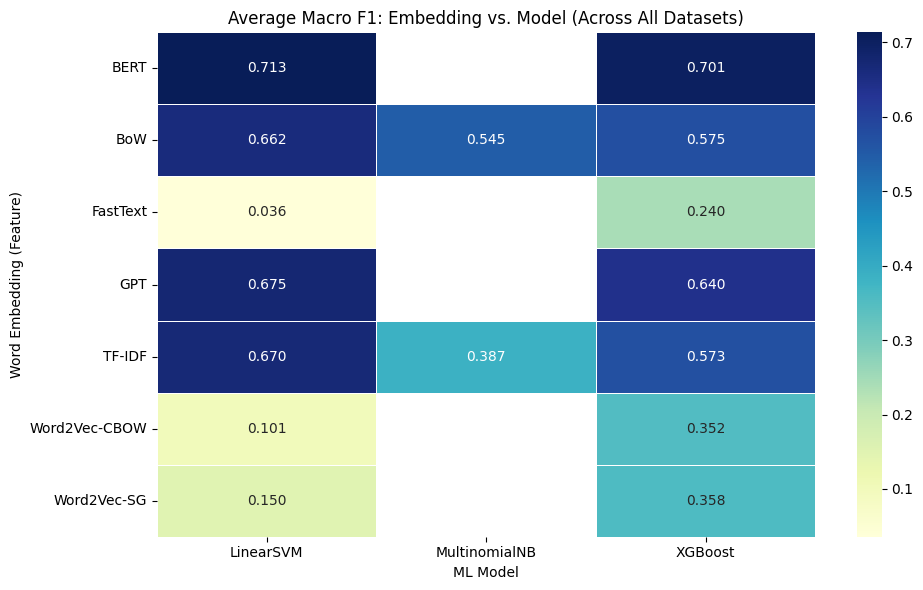

In [32]:
# CELL 1: Average Feature vs. Model Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))
# Calculate average F1 score for every Feature-Model combo across all datasets
pivot_df = results_df.pivot_table(
    index="Feature",
    columns="Model",
    values="Macro F1",
    aggfunc=np.mean
)

sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".3f", linewidths=.5)
plt.title("Average Macro F1: Embedding vs. Model (Across All Datasets)")
plt.ylabel("Word Embedding (Feature)")
plt.xlabel("ML Model")
plt.tight_layout()
plt.show()

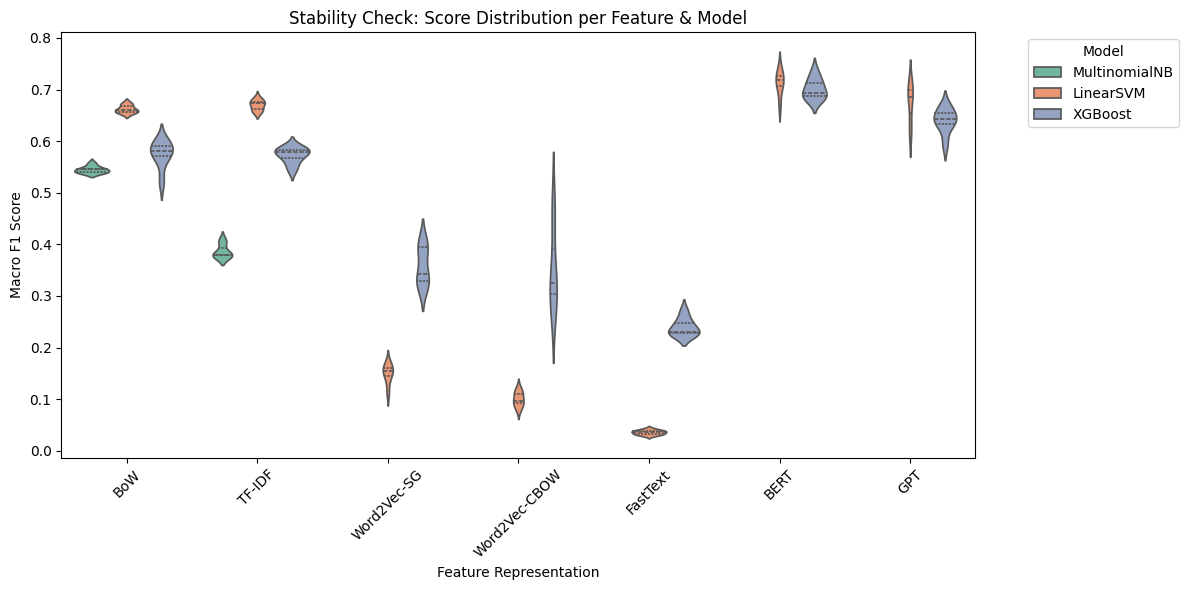

In [3]:
# CELL 2: Performance Distribution and Stability
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=results_df,
    x="Feature",
    y="Macro F1",
    hue="Model",
    split=False,
    inner="quartile",
    palette="Set2"
)

plt.title("Stability Check: Score Distribution per Feature & Model")
plt.ylabel("Macro F1 Score")
plt.xlabel("Feature Representation")
plt.xticks(rotation=45)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [4]:
!pip install --upgrade nbformat

In [5]:
# CELL 3: Precision vs. Recall Trade-off (Interactive)
import plotly.express as px

fig = px.scatter(
    results_df,
    x="Macro Precision",
    y="Macro Recall",
    color="Model",
    size="Accuracy",
    hover_data=["Dataset", "Feature", "Macro F1"],
    title="Trade-off: Precision vs. Recall (Bubble Size = Accuracy)",
    labels={
        "Macro Precision": "Macro Precision",
        "Macro Recall": "Macro Recall"
    },
    template="plotly_white"
)

# Add a diagonal line indicating perfect balance
fig.add_shape(
    type="line", line=dict(dash="dash", color="gray"),
    x0=results_df["Macro Precision"].min(), y0=results_df["Macro Recall"].min(),
    x1=results_df["Macro Precision"].max(), y1=results_df["Macro Recall"].max()
)

fig.update_layout(height=600, width=900)
fig.show()

In [6]:
# CELL 4: Radar Chart of the Top 3 Configurations
import plotly.graph_objects as go

# Get the top 3 absolute best rows based on Macro F1
top_3 = results_df.sort_values("Macro F1", ascending=False).head(3)

categories = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']

fig = go.Figure()

for index, row in top_3.iterrows():
    config_name = f"{row['Model']} | {row['Feature']} | {row['Dataset'][:10]}..."

    fig.add_trace(go.Scatterpolar(
        r=[row['Accuracy'], row['Macro Precision'], row['Macro Recall'], row['Macro F1']],
        theta=categories,
        fill='toself',
        name=config_name
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    showlegend=True,
    title="Metric Fingerprints: Top 3 Configurations",
    height=600
)
fig.show()

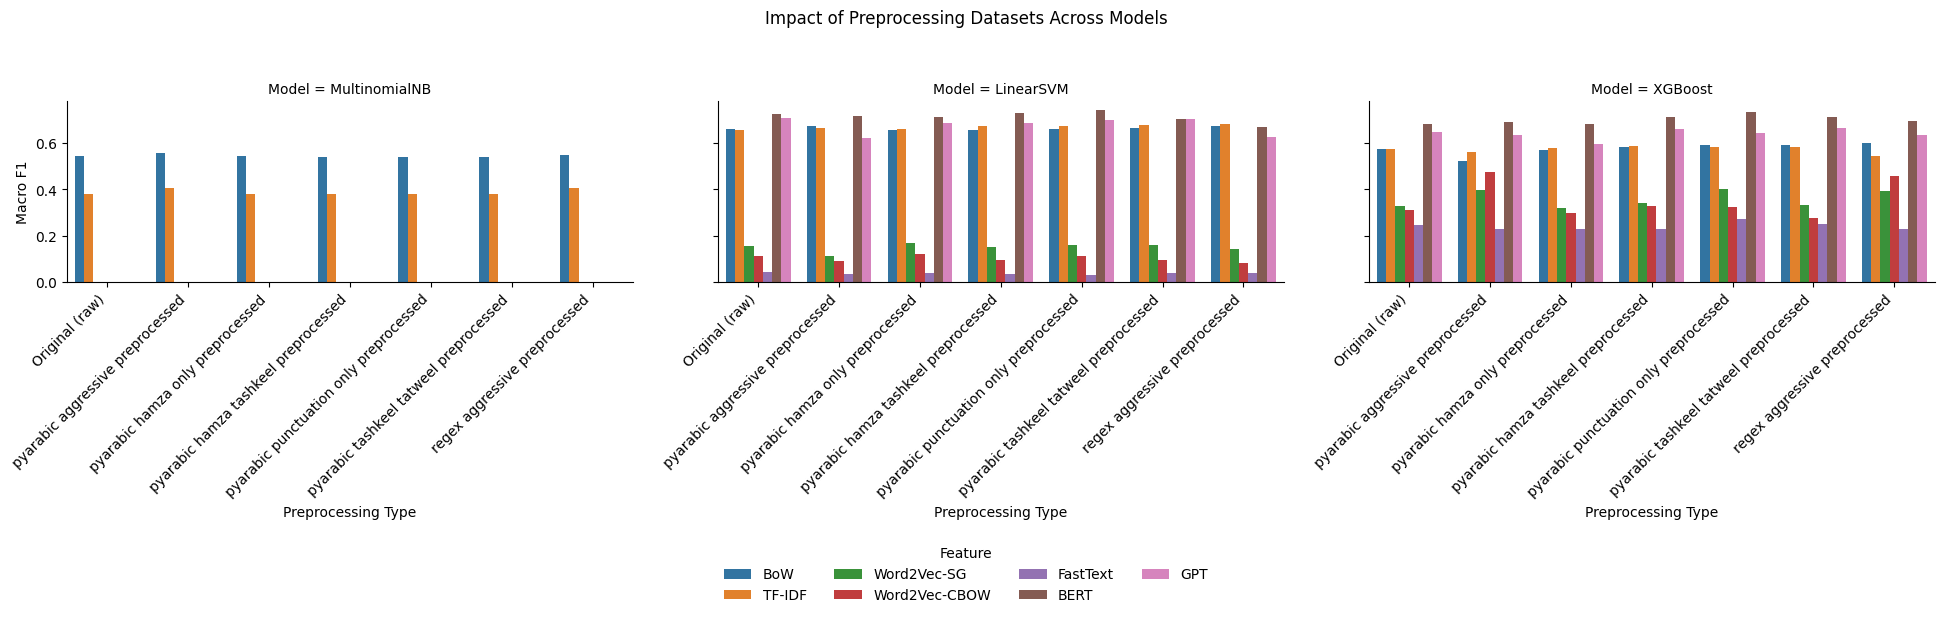

In [7]:
# CELL 5: Did Preprocessing Help? (Facet Grid)
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=results_df,
    x="Dataset",
    y="Macro F1",
    hue="Feature",
    col="Model",
    kind="bar",
    height=5,
    aspect=1.2
)

g.fig.suptitle("Impact of Preprocessing Datasets Across Models", y=1.05)
g.set_axis_labels("Preprocessing Type", "Macro F1")
g.set_xticklabels(rotation=45, ha="right")

# Move the legend to the bottom center and spread it horizontally
sns.move_legend(
    g, "upper center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=4,
    title="Feature",
    frameon=False
)

plt.tight_layout()
plt.show()

In [8]:
import plotly.express as px

fig = px.sunburst(
    results_df,
    path=['Dataset', 'Feature', 'Model'],
    values='Macro F1',
    color='Macro F1',
    color_continuous_scale='RdYlGn',
    title="Path to the Best F1 Score: Dataset → Feature → Model"
)

fig.update_layout(height=800)
fig.show()

In [9]:
!pip install --upgrade kaleido --quiet

In [26]:

import plotly.express as px

top_paths_df = results_df.sort_values('Macro F1', ascending=False).rename(columns={'Feature': 'Word Embedding (Feature)'}).head(15)
top_paths_df['Dataset'] = top_paths_df['Dataset'].str.replace(" preprocessed", "<br>preprocessed")

fig = px.parallel_categories(
    top_paths_df,
    dimensions=['Dataset', 'Word Embedding (Feature)', 'Model'],
    color='Macro F1',
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Top 15 Traditional Models Combinations: Dataset → Word Embedding (Feature) → Model"
)

# Added margin=dict(l=250, r=50) to give the text space on the left side
fig.update_layout(
    height=500,
    width=1200,
    margin=dict(l=225) 
)
# Make the column headers (labels) and the category names (ticks) bold
fig.update_traces(
    labelfont=dict(size=16, color="black", family="Arial"),
    tickfont=dict(size=14, color="black", family="Arial")
)
fig.write_image(
    "classification plots/Top 15 Traditional Models Combinations.png", 
    width=1200, 
    height=600, 
    scale=3
)
fig.show()

In [16]:
import plotly.express as px

top_paths_df = results_df.sort_values('Macro F1', ascending=False).rename(columns={'Feature': 'Word Embedding (Feature)'}).head(len(results_df))
top_paths_df['Dataset'] = top_paths_df['Dataset'].str.replace(" preprocessed", "<br>preprocessed")
fig = px.parallel_categories(
    top_paths_df,
    dimensions=['Dataset', 'Word Embedding (Feature)', 'Model'],
    color='Macro F1',
    color_continuous_scale=px.colors.sequential.Plasma,
    title="All Traditional Models Combinations: Dataset → Word Embedding (Feature) → Model"
)

fig.update_layout(
    height=500,
    margin=dict(l=225) 
)
fig.show()
fig.write_image(
    "classification plots/All Traditional Models Combinations.png", 
    width=1200, 
    height=600, 
    scale=3
)

## 15. Summary Tables

In [ ]:
if not results_df.empty:
    best_by_dataset = (
        results_df.sort_values('Macro F1', ascending=False)
        .groupby("Dataset")
        .head(1)
        .reset_index(drop=True)
    )
best_by_dataset


,Dataset,Feature,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,pyarabic punctuation only preprocessed,BERT,LinearSVM,0.761477,0.745705,0.745722,0.741922,0.761681
1,pyarabic hamza tashkeel preprocessed,BERT,LinearSVM,0.785429,0.742916,0.717600,0.728522,0.785016
2,Original (raw),BERT,LinearSVM,0.761477,0.763425,0.705558,0.723274,0.760899
3,pyarabic aggressive preprocessed,BERT,LinearSVM,0.742515,0.727265,0.718045,0.718019,0.743113
4,pyarabic tashkeel tatweel preprocessed,BERT,XGBoost,0.777445,0.766084,0.678990,0.713737,0.776276
5,pyarabic hamza only preprocessed,BERT,LinearSVM,0.748503,0.735654,0.696728,0.709731,0.748497
6,regex aggressive preprocessed,BERT,XGBoost,0.758483,0.772828,0.655720,0.693718,0.756271
